# TP Filtrage : Effets de retard FIR et IIR

Le fichier data/string_1.wav est un son mono codé sur 16 bits signés. On le convertit en flottants et on divise par 32768 pour obtenir des valeurs dans $[-1,1[$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio, display

fs, audio = wavfile.read("data/string_1.wav")
audio = audio.astype(float) / 32768

Matplotlib is building the font cache; this may take a moment.


On prend un retard de $0{,}25$ s, soit $D=0{,}25f_s=11025$ échantillons

Pour le FIR, on choisit un écho d'amplitude $0{,}6$. Pour le IIR, on prend un gain d'entrée de 1 et un retour de $0{,}6$. Les deux filtres auront ainsi le même son direct et le même premier écho

On suppose les entrées et sorties nulles pour $n<0$, et $D\geq1$

In [2]:
delay = round(0.25 * fs)
echo = 0.6
gain = 1.0
feedback = 0.6

## 1. Retard FIR

On considere l'equation :

$$s[n]=e[n]+\alpha e[n-D]$$

En prenant $e[n]=\delta[n]$, on obtient :

$$h_{\mathrm{FIR}}[n]=\delta[n]+\alpha\delta[n-D]$$

Il reste donc deux coefficients non nuls : 1 en zéro et $\alpha$ en $D$.

On applique directement l'équation temporelle. Les $D$ zéros ajoutés au son permettent de conserver la fin de l'écho.

In [3]:
def fir_delay(samples, delay, echo):
    out = samples.copy()
    out[delay:] += echo * samples[:-delay]
    return out


audio_fir = fir_delay(np.pad(audio, (0, delay)), delay, echo)

impulse = np.zeros(2 * delay + 1)
impulse[0] = 1
h_fir = fir_delay(impulse, delay, echo)

## 2. Retard IIR

Cette fois, le retard porte sur la sortie :

$$s[n]=\alpha e[n]+\beta s[n-D]$$

En remplaçant successivement les sorties retardées :

$$s[n]=\alpha e[n]+\alpha\beta e[n-D]+\alpha\beta^2e[n-2D]+\cdots$$

Pour un $n$ fixé, les termes avec $n-kD<0$ sont nuls. Avec une impulsion en entrée, on trouve donc :

$$h_{\mathrm{IIR}}[n]=\alpha\sum_{k=0}^{\infty}\beta^k\delta[n-kD]$$

Le coefficient en $kD$ vaut $\alpha\beta^k$. La réponse est infinie lorsque $\alpha\ne0$ et $\beta\ne0$

In [4]:
def iir_delay(samples, delay, gain, feedback):
    out = gain * samples.copy()
    for idx in range(delay, len(samples)):
        out[idx] += feedback * out[idx - delay]
    return out

### Stabilité

Pour $0\leq\beta<1$, la somme géométrique donne :

$$\sum_n |h_{\mathrm{IIR}}[n]|=\alpha\sum_{k=0}^{\infty}\beta^k=\frac{\alpha}{1-\beta}$$

Si $|e[n]|\leq M$, alors $|s[n]|\leq M\alpha/(1-\beta)$. Une entrée bornée produit donc une sortie bornée

Pour $\beta=1$, les échos ne décroissent plus. Une entrée constante égale à 1 pour $n\geq0$ donne $s[kD]=\alpha(k+1)$, qui diverge. Pour $\beta>1$, même la réponse à une impulsion diverge, car $\alpha\beta^k\to+\infty$

Avec les paramètres positifs de l'énoncé, le filtre est donc stable si et seulement si $\beta<1$. Notre choix $\beta=0{,}6$ satisfait cette condition

### Calcul des échos

Un tableau fini ne peut pas contenir toute la réponse IIR. On garde les coefficients d'indices $k=0,\ldots,K-1$. La somme des amplitudes restantes vaut :

$$\sum_{k=K}^{\infty}\alpha\beta^k=\frac{\alpha\beta^K}{1-\beta}$$

On choisit $K$ pour que cette somme soit inférieure à $10^{-6}$. Cette borne contrôle aussi l'erreur sur la réponse fréquentielle, par l'inégalité triangulaire

Après la fin du son, on calcule encore $(K-1)D$ échantillons. Au-delà, seuls des retards d'ordre $k\geq K$ peuvent contribuer. La sortie omise est donc bornée par $\max|e|\,10^{-6}$

In [5]:
tol = 1e-6
echo_count = 1
while gain * feedback**echo_count / (1 - feedback) > tol:
    echo_count += 1

impulse = np.zeros(echo_count * delay)
impulse[0] = 1
h_iir = iir_delay(impulse, delay, gain, feedback)

tail = (echo_count - 1) * delay
audio_iir = iir_delay(np.pad(audio, (0, tail)), delay, gain, feedback)

En filtrant une impulsion, on affiche maintenant les deux premieres secondes

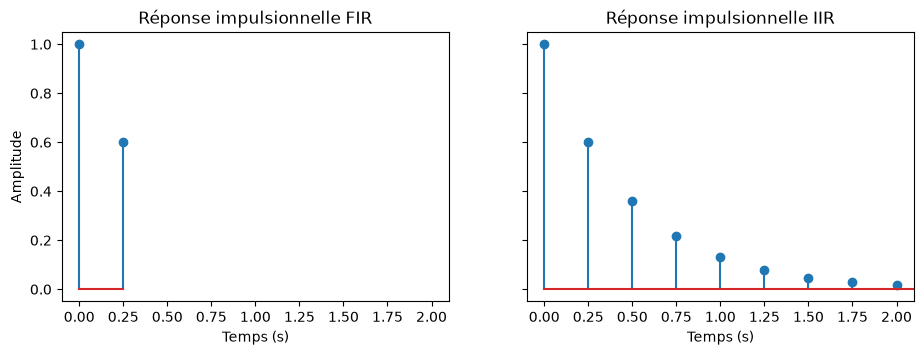

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for idx, response in enumerate([h_fir, h_iir]):
    pos = np.flatnonzero(response)
    axes[idx].stem(pos / fs, response[pos])
    axes[idx].set_xlim(-0.1, 2.1)
    axes[idx].set_xlabel("Temps (s)")
    axes[idx].set_title(["Réponse impulsionnelle FIR", "Réponse impulsionnelle IIR"][idx])
axes[0].set_ylabel("Amplitude")
plt.show()

Le FIR s'arrête après le premier écho. L'IIR ajoute des copies aux instants $2D,3D,\ldots$. Les premières amplitudes sont $1$, $0{,}6$, $0{,}36$ et $0{,}216$, comme le prévoit $\alpha\beta^k$

Pour illustrer la limite de stabilité, on applique aussi l'IIR à une impulsion et à un échelon. On relève les sorties aux instants $kD$

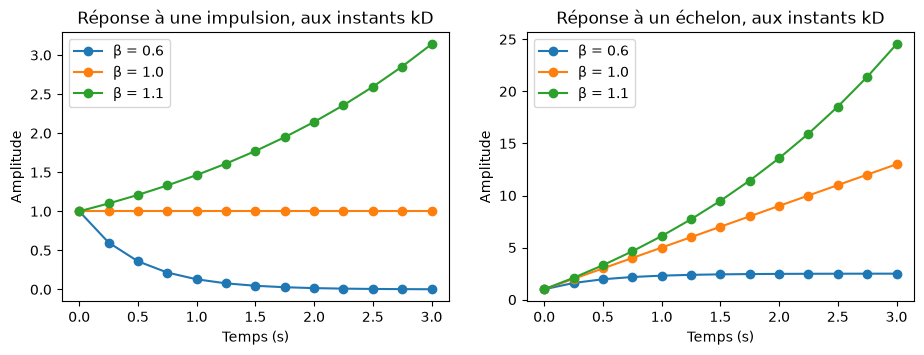

In [7]:
probe = np.zeros(12 * delay + 1)
probe[0] = 1
step = np.ones_like(probe)
times = np.arange(13) * delay / fs

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for beta_val in [0.6, 1.0, 1.1]:
    response = iir_delay(probe, delay, gain, beta_val)
    step_out = iir_delay(step, delay, gain, beta_val)
    axes[0].plot(times, response[::delay], "o-", label=f"β = {beta_val}")
    axes[1].plot(times, step_out[::delay], "o-", label=f"β = {beta_val}")
for axis in axes:
    axis.set_xlabel("Temps (s)")
    axis.set_ylabel("Amplitude")
    axis.legend()
axes[0].set_title("Réponse à une impulsion, aux instants kD")
axes[1].set_title("Réponse à un échelon, aux instants kD")
plt.show()

Pour $\beta=0{,}6$, la réponse à l'échelon tend vers $1/(1-0{,}6)=2{,}5$. Pour $\beta=1$, la réponse impulsionnelle reste bornée, mais la réponse à l'échelon croît. Une réponse impulsionnelle bornée ne suffit donc pas à assurer la stabilité.

## 3. Réponses fréquentielles

On calcule numériquement la transformée de Fourier des réponses impulsionnelles. Avec $f$ en hertz :

$$H(f)=\sum_n h[n]e^{-2i\pi fn/f_s}$$

En remplaçant $h$ par les expressions obtenues :

$$H_{\mathrm{FIR}}(f)=1+\alpha e^{-2i\pi fD/f_s}$$

$$H_{\mathrm{IIR}}(f)=\alpha\sum_{k=0}^{\infty}\left(\beta e^{-2i\pi fD/f_s}\right)^k=\frac{\alpha}{1-\beta e^{-2i\pi fD/f_s}}$$

La seconde égalité utilise $\beta<1$. On compare les FFT aux formules pour contrôler les calculs. La réponse FIR est complétée par des zéros pour utiliser la même grille que l'IIR.

Les deux réponses sont périodiques en fréquence, de période $f_s/D=4$ Hz. En effet, ajouter $f_s/D$ à $f$ multiplie l'exponentielle par $e^{-2i\pi}=1$. On affiche cinq périodes pour voir les oscillations.

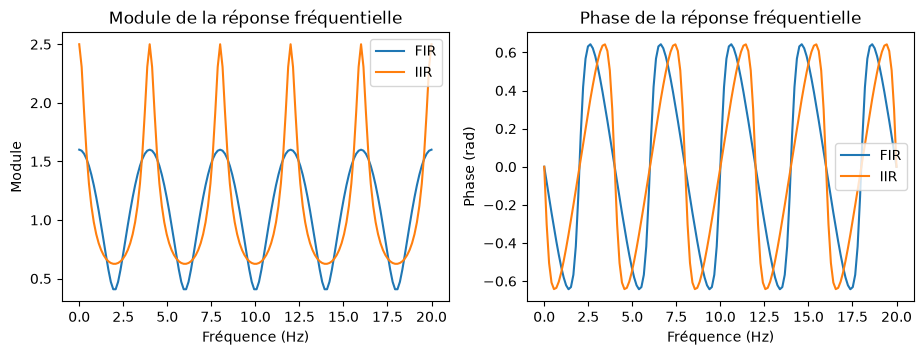

In [8]:
fft_len = len(h_iir)
freq = np.fft.rfftfreq(fft_len, d=1 / fs)
spec_fir = np.fft.rfft(h_fir, n=fft_len)
spec_iir = np.fft.rfft(h_iir)

phase = np.exp(-2j * np.pi * freq * delay / fs)
ref_fir = 1 + echo * phase
ref_iir = gain / (1 - feedback * phase)
assert np.max(np.abs(spec_fir - ref_fir)) < 1e-10
assert np.max(np.abs(spec_iir - ref_iir)) < tol

view = freq <= 5 * fs / delay
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for spectrum, label in [(spec_fir, "FIR"), (spec_iir, "IIR")]:
    axes[0].plot(freq[view], np.abs(spectrum[view]), label=label)
    axes[1].plot(freq[view], np.angle(spectrum[view]), label=label)
for axis in axes:
    axis.set_xlabel("Fréquence (Hz)")
    axis.legend()
axes[0].set_ylabel("Module")
axes[1].set_ylabel("Phase (rad)")
axes[0].set_title("Module de la réponse fréquentielle")
axes[1].set_title("Phase de la réponse fréquentielle")
plt.show()

En multipliant chaque réponse par son conjugué, avec $\theta=2\pi fD/f_s$, on obtient :

$$|H_{\mathrm{FIR}}(f)|^2=1+\alpha^2+2\alpha\cos\theta$$

$$|H_{\mathrm{IIR}}(f)|^2=\frac{\alpha^2}{1+\beta^2-2\beta\cos\theta}$$

Comme $-1\leq\cos\theta\leq1$, le module FIR varie entre $|1-\alpha|=0{,}4$ et $1+\alpha=1{,}6$. Celui de l'IIR varie entre $\alpha/(1+\beta)=0{,}625$ et $\alpha/(1-\beta)=2{,}5$. Les courbes retrouvent ces valeurs, à l'échantillonnage fréquentiel près

Les maxima se situent aux multiples de 4 Hz. Les minima se trouvent à mi-distance. Le retard produit donc une alternance régulière de fréquences renforcées et atténuées, appelée filtrage en peigne

## 4. Paramètres et comparaison

| Paramètre | Effet déduit des formules |
|---|---|
| $D$ | Les échos sont espacés de $D/f_s$ secondes. Augmenter $D$ les éloigne et réduit l'espacement $f_s/D$ des pics fréquentiels |
| $\alpha$ du FIR | Il règle uniquement l'amplitude de la copie retardée. Le son direct garde un coefficient égal à 1 |
| $\alpha$ de l'IIR | Il multiplie le son direct et tous les échos. Il ne change pas la condition de stabilité tant qu'il reste positif |
| $\beta$ de l'IIR | Le rapport entre deux échos successifs vaut $\beta$. Plus il est proche de 1 par valeurs inférieures, plus la décroissance est lente. À partir de 1, le filtre est instable |

Le FIR donne $e[n]+0{,}6e[n-D]$. L'IIR contient les mêmes termes, puis $0{,}36e[n-2D]+0{,}216e[n-3D]+\cdots$. Il prolonge donc davantage le son. Les gains fréquentiels different car les copies supplementaires se combinent aussi avec le signal direct

Les lecteurs suivent l'ordre : original, FIR, IIR. On utilise un facteur de volume commun pour éviter l'écretage sans modifier les rapports d'amplitude entre les trois sons

In [9]:
level = max(np.max(np.abs(audio)), np.max(np.abs(audio_fir)), np.max(np.abs(audio_iir)))
display(Audio(audio / level, rate=fs, normalize=False))
display(Audio(audio_fir / level, rate=fs, normalize=False))
display(Audio(audio_iir / level, rate=fs, normalize=False))